In [14]:
!pip install xgboost seaborn joblib

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Configuration
MASTER_PATH = "../data/master"
MODELS_PATH = "../models"
REPORTS_PATH = "../reports"

os.makedirs(REPORTS_PATH, exist_ok=True)

In [17]:
print("="*60)
print("FINAL MODEL TRAINING - RANDOM FOREST")
print("="*60)

# Load data
print("\n Loading master dataset...")
df = pd.read_csv(f"{MASTER_PATH}/tourism_master_final.csv")
features = joblib.load(f"{MODELS_PATH}/feature_list_final.pkl")

print(f"   Dataset: {df.shape}")
print(f"   Features: {len(features)}")

# Prepare features and target
X = df[features]
y = df['Tourist_Arrivals']

# Time-based split
print("\n Creating time-based splits...")
df_sorted = df.sort_values(['Year', 'Month_Num'])
X_sorted = X.loc[df_sorted.index]
y_sorted = y.loc[df_sorted.index]

train_mask = df_sorted['Year'] <= 2022
val_mask = df_sorted['Year'] == 2023
test_mask = df_sorted['Year'] == 2024

X_train, X_val, X_test = X_sorted[train_mask], X_sorted[val_mask], X_sorted[test_mask]
y_train, y_val, y_test = y_sorted[train_mask], y_sorted[val_mask], y_sorted[test_mask]

print(f"\n Split summary:")
print(f"   Train: {len(X_train):,} samples (2019-2022)")
print(f"   Validation: {len(X_val):,} samples (2023)")
print(f"   Test: {len(X_test):,} samples (2024)")

# Feature scaling
print("\n Scaling features...")
binary_cols = ['Is_Top10', 'Is_Consistent_Top10', 'Is_Peak_Month', 
               'Is_COVID_Year', 'Is_Post_COVID']
categorical_cols = [col for col in features if col.startswith('Quarter_')]

cols_to_scale = [col for col in features 
                 if col not in binary_cols + categorical_cols 
                 and col not in ['Year', 'Month_Num', 'Country_Code']
                 and not col.endswith('_log')]

print(f"   Scaling {len(cols_to_scale)} numeric features")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

FINAL MODEL TRAINING - RANDOM FOREST

 Loading master dataset...
   Dataset: (13632, 47)
   Features: 46

 Creating time-based splits...

 Split summary:
   Train: 9,036 samples (2019-2022)
   Validation: 2,280 samples (2023)
   Test: 2,316 samples (2024)

 Scaling features...
   Scaling 35 numeric features



 Training Random Forest with hyperparameter tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 Best parameters found:
   max_depth: 7
   max_features: None
   min_samples_leaf: 8
   min_samples_split: 5
   n_estimators: 459

 Evaluating model...

 Validation Performance (2023):
   MAE: 137
   RMSE: 723
   R²: 0.9282

 Test Performance (2024):
   MAE: 178
   RMSE: 991
   R²: 0.9202

 Feature importance analysis...

 Top 15 most important features:
               feature  importance
           Lag_1_Month    0.757031
             Growth_3M    0.058179
          Market_Share    0.041066
       Rolling_Mean_12    0.034530
  Avg_Country_Arrivals    0.033025
            Growth_12M    0.019225
        Rolling_Mean_3    0.012800
             Month_Num    0.009386
Total_Country_Arrivals    0.006514
        Rolling_Mean_6    0.006227
        Rolling_Std_12    0.006040
           Lag_3_Month    0.002897
          Lag_12_Month    0.002072
         Rolling_Std_3    0.001710


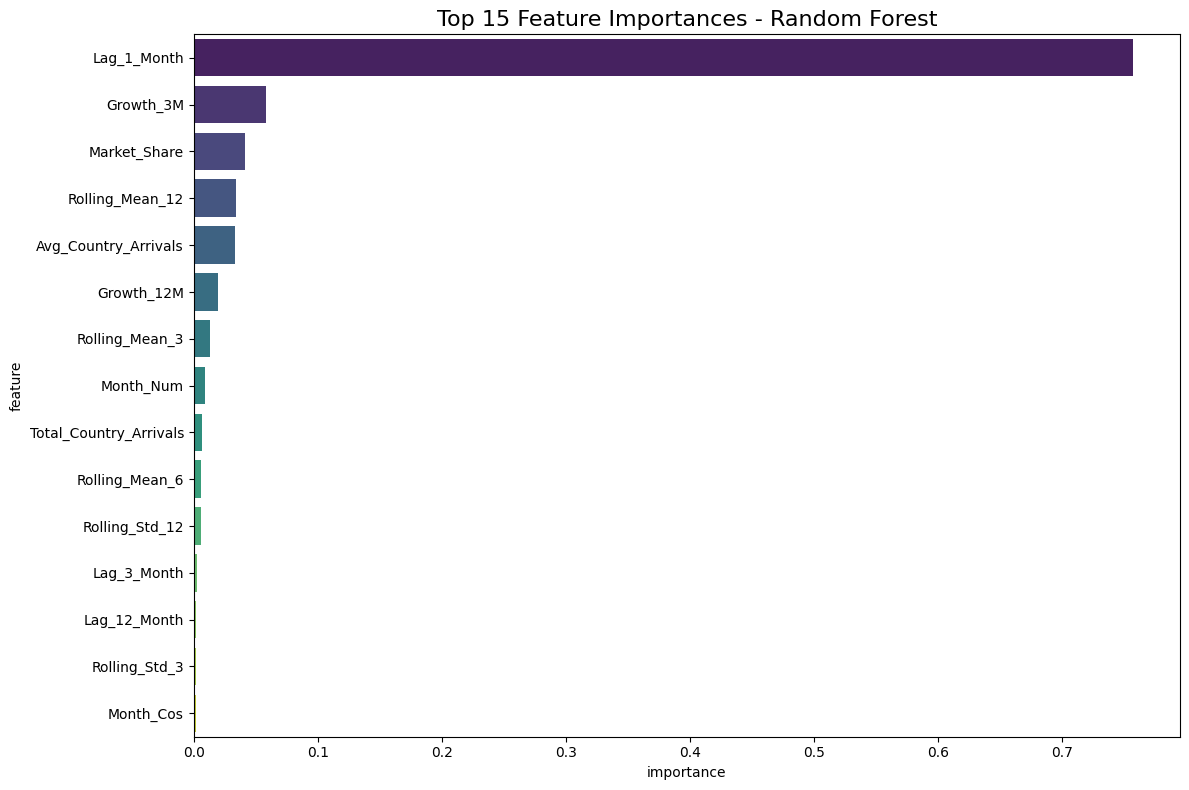

In [18]:
# ============================================
# RANDOM FOREST
# ============================================
print("\n Training Random Forest with hyperparameter tuning...")

# Define parameter distribution
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Randomized search
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print(f"\n Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")

best_rf = random_search.best_estimator_

# ============================================
# EVALUATION
# ============================================
print("\n Evaluating model...")

# Validation predictions
y_val_pred = best_rf.predict(X_val_scaled)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

# Test predictions
y_test_pred = best_rf.predict(X_test_scaled)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n Validation Performance (2023):")
print(f"   MAE: {val_mae:,.0f}")
print(f"   RMSE: {val_rmse:,.0f}")
print(f"   R²: {val_r2:.4f}")

print(f"\n Test Performance (2024):")
print(f"   MAE: {test_mae:,.0f}")
print(f"   RMSE: {test_rmse:,.0f}")
print(f"   R²: {test_r2:.4f}")

# ============================================
# FEATURE IMPORTANCE
# ============================================
print("\n Feature importance analysis...")

importance_df = pd.DataFrame({
    'feature': features,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest', fontsize=16)
plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/rf_feature_importance.png", dpi=150)
plt.show()

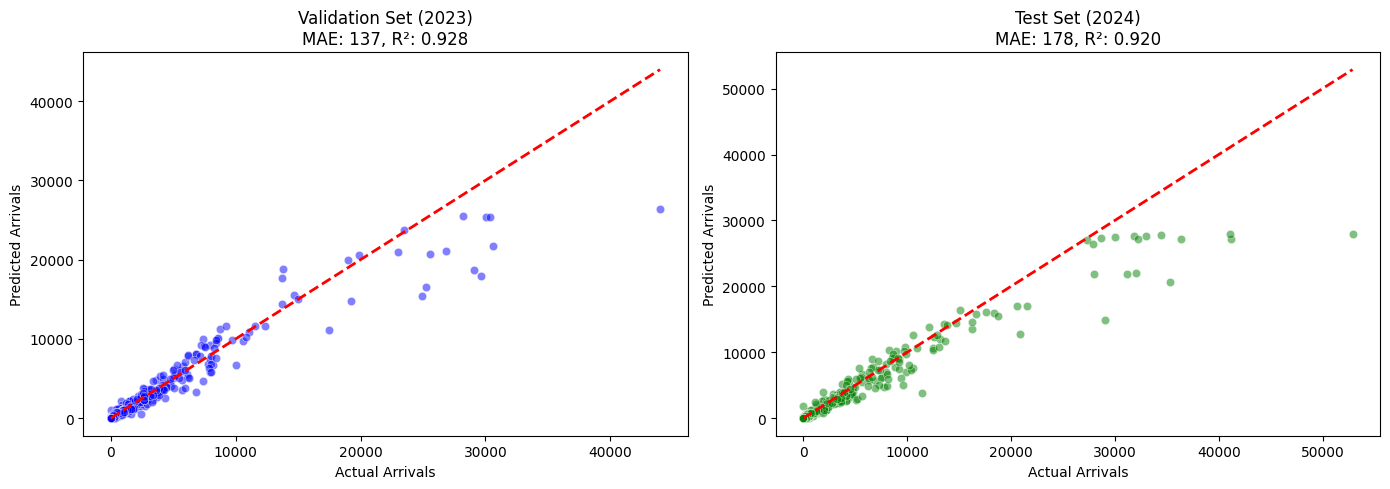

In [19]:
# ============================================
# ACTUAL VS PREDICTED PLOT
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation
axes[0].scatter(y_val, y_val_pred, alpha=0.5, c='blue', edgecolors='w', linewidth=0.5)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Arrivals')
axes[0].set_ylabel('Predicted Arrivals')
axes[0].set_title(f'Validation Set (2023)\nMAE: {val_mae:,.0f}, R²: {val_r2:.3f}')

# Test
axes[1].scatter(y_test, y_test_pred, alpha=0.5, c='green', edgecolors='w', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Arrivals')
axes[1].set_ylabel('Predicted Arrivals')
axes[1].set_title(f'Test Set (2024)\nMAE: {test_mae:,.0f}, R²: {test_r2:.3f}')

plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/rf_actual_vs_predicted.png", dpi=150)
plt.show()

In [20]:
# ============================================
# SAVE MODELS
# ============================================
print("\n Saving model and artifacts...")

joblib.dump(best_rf, f"{MODELS_PATH}/random_forest_final.pkl")
joblib.dump(scaler, f"{MODELS_PATH}/scaler_final.pkl")

# Save performance metrics
metrics = {
    'algorithm': 'Random Forest',
    'val_mae': val_mae,
    'val_rmse': val_rmse,
    'val_r2': val_r2,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_r2': test_r2,
    'best_params': random_search.best_params_,
    'feature_importance': importance_df.to_dict()
}

joblib.dump(metrics, f"{MODELS_PATH}/performance_metrics_final.pkl")

print("\n" + "="*60)
print(" MODEL TRAINING COMPLETE!")
print("="*60)
print(f"\n Final Model Performance:")
print(f"   Algorithm: Random Forest")
print(f"   Test MAE: {test_mae:,.0f}")
print(f"   Test RMSE: {test_rmse:,.0f}")
print(f"   Test R²: {test_r2:.4f}")
print(f"\n Models saved to: {MODELS_PATH}")


 Saving model and artifacts...

 MODEL TRAINING COMPLETE!

 Final Model Performance:
   Algorithm: Random Forest
   Test MAE: 178
   Test RMSE: 991
   Test R²: 0.9202

 Models saved to: ../models
